# Успеваемость студентов (Student Performance)

## О данных (About Dataset)
Этот набор данных содержит данные об успеваемости 1000 учащихся по трём предметам: математике, чтению и письму. Он включает в себя профили учащихся и социально-экономическую информацию, что делает его идеальным для образовательных исследований, статистического анализа и задач машинного обучения, связанных с результатами учащихся.<br>
(This dataset consists of academic performance data for 1000 students across three subjects: **math, reading, and writing**. The dataset includes student profile and socio-economic details, making it ideal for educational research, statistical analysis, and machine learning tasks related to student outcomes)

### Импортируем необходимые модули

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

### Загружаем данные

In [2]:
path = '../Datasets/StudentsPerformance.csv'

In [3]:
df = pd.read_csv(path)

In [4]:
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df[df['test preparation course'] == 'none'].head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78


### Посмотрим общую информацию о датасете

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


<b>Записей об успеваемости студентов действительно ровно одна тысяча. Столбцы пола, обезличенные данные по этнической принадлежности, образовании родителей, питании и подготовительных курсах имеют строчный вид данных, столбцы оценок по математике, чтению и письму представлены в целочисленном виде. Пропусков данных нет</b>

### Можно выполнить преобразования типов данных для ускорения выполнения кода (В конкретном небольшом датасете влияние будет малозаметно)

In [7]:
df['gender'] = df['gender'].astype('category')
df['race/ethnicity'] = df['race/ethnicity'].astype('category')
df['parental level of education'] = df['parental level of education'].astype('category')
df['lunch'] = df['lunch'].astype('category')
df['test preparation course'] = df['test preparation course'].astype('category')
df['math score'] = df['math score'].astype('uint8')
df['reading score'] = df['reading score'].astype('uint8')
df['writing score'] = df['writing score'].astype('uint8')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   gender                       1000 non-null   category
 1   race/ethnicity               1000 non-null   category
 2   parental level of education  1000 non-null   category
 3   lunch                        1000 non-null   category
 4   test preparation course      1000 non-null   category
 5   math score                   1000 non-null   uint8   
 6   reading score                1000 non-null   uint8   
 7   writing score                1000 non-null   uint8   
dtypes: category(5), uint8(3)
memory usage: 8.7 KB


#### Количество уникальных значений в каждом столбце

In [9]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

## Анализ успеваемости

#### Найдем студентов с наивысшими баллами хотя бы по одному предмету

In [10]:
print('Всего студентов с наивысшими оценками: ', len(df[(df['math score'] == 100) | (df['reading score'] == 100) | (df['writing score'] == 100)]))
df[(df['math score'] == 100) | (df['reading score'] == 100) | (df['writing score'] == 100)].head(5)

Всего студентов с наивысшими оценками:  23


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
106,female,group D,master's degree,standard,none,87,100,100
114,female,group E,bachelor's degree,standard,completed,99,100,100
149,male,group E,associate's degree,free/reduced,completed,100,100,93
165,female,group C,bachelor's degree,standard,completed,96,100,100
179,female,group D,some high school,standard,completed,97,100,100


#### Найдем студентов у которых 100 баллов по всем предметам:

In [11]:
print ('Всего "стобальников": ', len(df[(df['math score'] == 100) & (df['reading score'] == 100) & (df['writing score'] == 100)]))
df[(df['math score'] == 100) & (df['reading score'] == 100) & (df['writing score'] == 100)]

Всего "стобальников":  3


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
458,female,group E,bachelor's degree,standard,none,100,100,100
916,male,group E,bachelor's degree,standard,completed,100,100,100
962,female,group E,associate's degree,standard,none,100,100,100


#### Найдем студентов с наихудшей успеваемостью (имееет по одному из предметов 0 баллов):

In [12]:
print ('Имеют 0 баллов: ', len(df[(df['math score'] == 0) | (df['reading score'] == 0) | (df['writing score'] == 0)]))
df[(df['math score'] == 0) | (df['reading score'] == 0) | (df['writing score'] == 0)]

Имеют 0 баллов:  1


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
59,female,group C,some high school,free/reduced,none,0,17,10




### Получим распределение средней оценки группам и полу

In [13]:
avgscore_df = df.groupby(['gender', 'race/ethnicity'], observed=True).agg(
    math_avg=('math score', 'mean'),
    reading_avg=('reading score', 'mean'),
    writing_avg=('writing score', 'mean')
).round().astype(int).reset_index()

In [14]:
avgscore_df

,gender,race/ethnicity,math_avg,reading_avg,writing_avg
0,female,group A,59,69,68
1,female,group B,61,71,70
2,female,group C,62,72,72
3,female,group D,65,74,75
4,female,group E,71,76,76
5,male,group A,64,62,59
6,male,group B,66,63,60
7,male,group C,68,65,63
8,male,group D,69,66,65
9,male,group E,77,70,67


#### Добавим столбец средней оценки по группам

In [15]:
avgscore_df['overall_avg'] = avgscore_df[['math_avg', 'reading_avg', 'writing_avg']].mean(axis=1).round().astype(int)

In [16]:
avgscore_df

,gender,race/ethnicity,math_avg,reading_avg,writing_avg,overall_avg
0,female,group A,59,69,68,65
1,female,group B,61,71,70,67
2,female,group C,62,72,72,69
3,female,group D,65,74,75,71
4,female,group E,71,76,76,74
5,male,group A,64,62,59,62
6,male,group B,66,63,60,63
7,male,group C,68,65,63,65
8,male,group D,69,66,65,67
9,male,group E,77,70,67,71


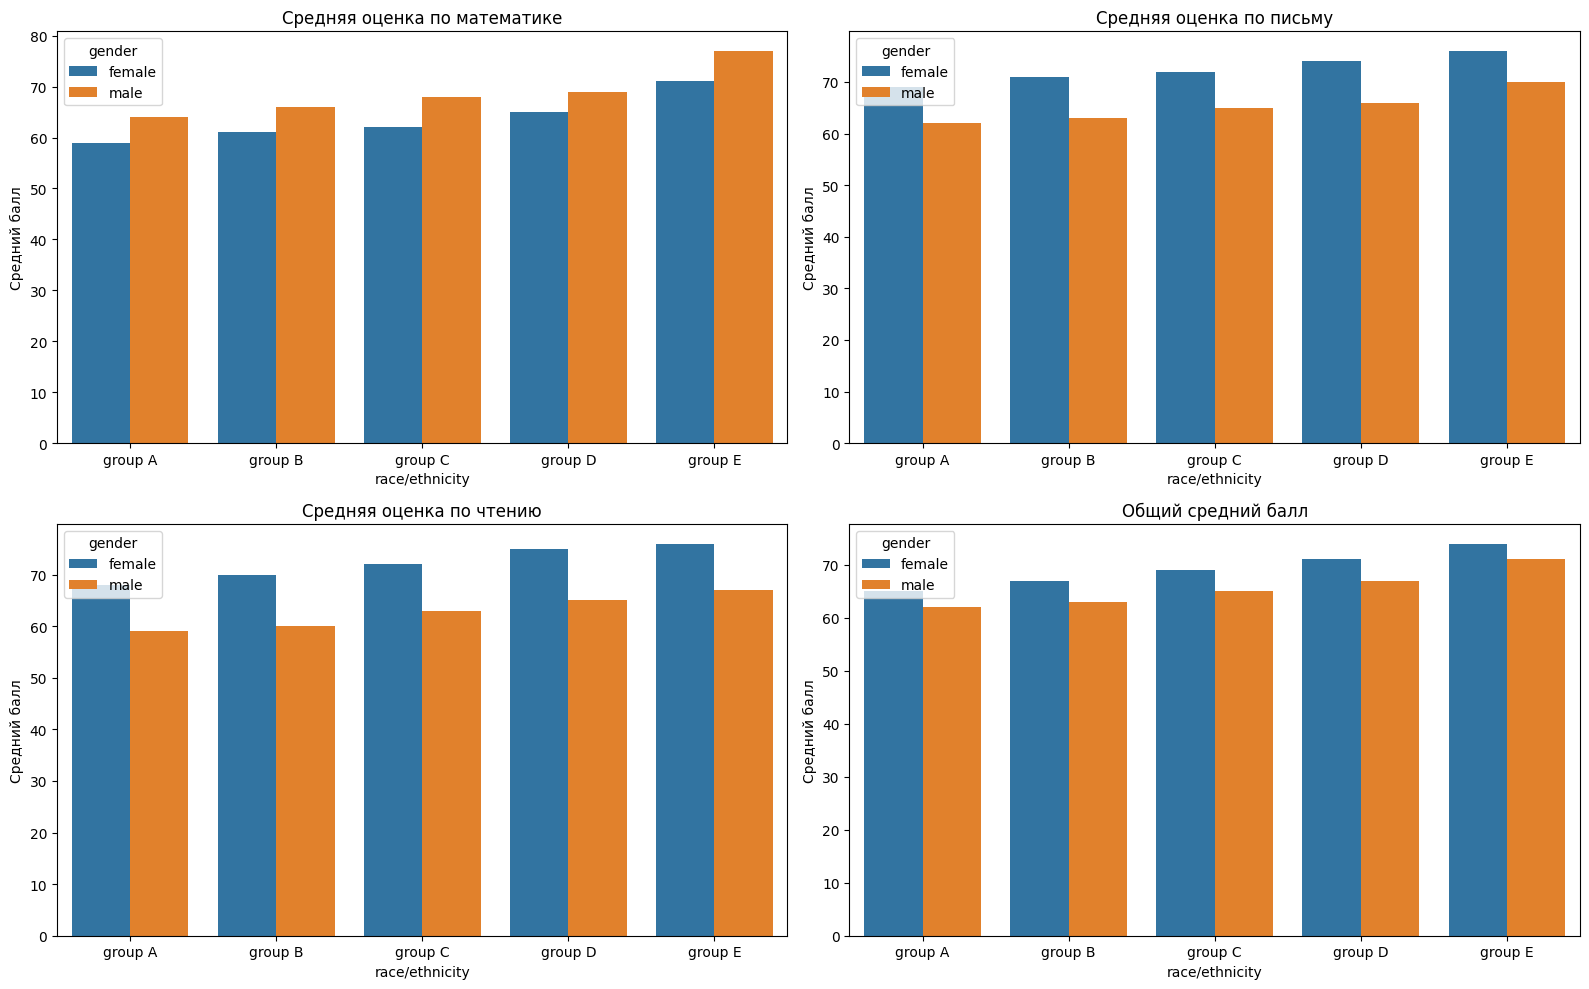

In [17]:
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
sns.barplot(avgscore_df, x = 'race/ethnicity', y = 'math_avg', hue = 'gender')
plt.title('Средняя оценка по математике')
plt.ylabel('Средний балл')

plt.subplot(2, 2, 2)
sns.barplot(avgscore_df, x = 'race/ethnicity', y = 'reading_avg', hue = 'gender')
plt.title('Средняя оценка по письму')
plt.ylabel('Средний балл')

plt.subplot(2, 2, 3)
sns.barplot(avgscore_df, x = 'race/ethnicity', y = 'writing_avg', hue = 'gender')
plt.title('Средняя оценка по чтению')
plt.ylabel('Средний балл')

plt.subplot(2, 2, 4)
sns.barplot(avgscore_df, x = 'race/ethnicity', y = 'overall_avg', hue = 'gender')
plt.title('Общий средний балл')
plt.ylabel('Средний балл')

plt.tight_layout()
plt.show()

# Проверка статистических гипотез (на примере группы А)

## 1. Н0 - статистические различия успеваемости в группе А между студентами и студентками отсутствуют

### 1.1. Различия успеваемости по математике

#### Выборка групп:

In [18]:
group_A = df[(df['gender'] == 'female') & (df['race/ethnicity'] == 'group A')]['math score']
group_B = df[(df['gender'] == 'male') & (df['race/ethnicity'] == 'group A')]['math score']

#### Тест на нормальность Шапиро-Уилка/Shapiro-Wilk test for normality

In [19]:
shapiro_A = stats.shapiro(group_A)
shapiro_B = stats.shapiro(group_B)
print("Shapiro A p =", shapiro_A.pvalue)
if shapiro_A.pvalue > 0.05:
    print ('- распределение близко к нормальному')
else:
    print('- не нормальное распределение')
print("Shapiro B p =", shapiro_B.pvalue)
if shapiro_B.pvalue > 0.05:
    print ('- распределение близко к нормальному')
else:
    print('- не нормальное распределение')

Shapiro A p = 0.6523340671666013
- распределение близко к нормальному
Shapiro B p = 0.9547782278704576
- распределение близко к нормальному


Распределение довольно близко к нормальному. Оценим визуально с использование Q-Q plot (quantile-quantile)

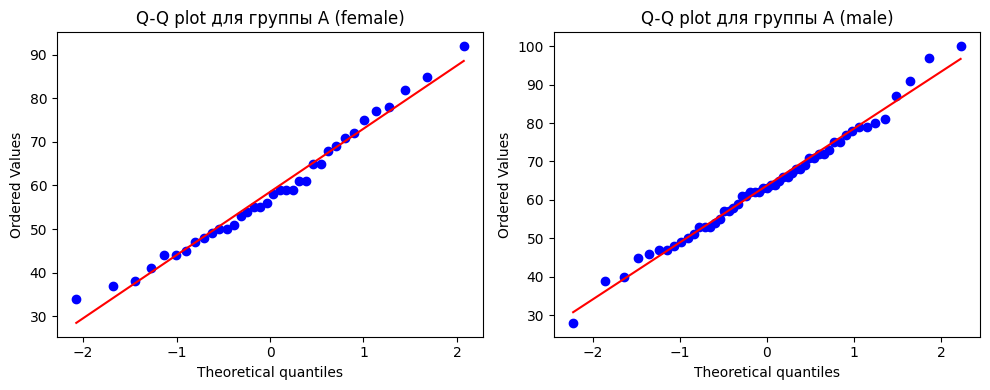

In [20]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
stats.probplot(group_A, dist="norm", plot=plt)
plt.title("Q-Q plot для группы A (female)")

plt.subplot(1, 2, 2)
stats.probplot(group_B, dist="norm", plot=plt)
plt.title("Q-Q plot для группы A (male)")

plt.tight_layout()
plt.show()

Точки вдоль прямой линии с небольшим отклонением на концах — нормальность «достаточная».

Проведем еще одну визульную оценку.

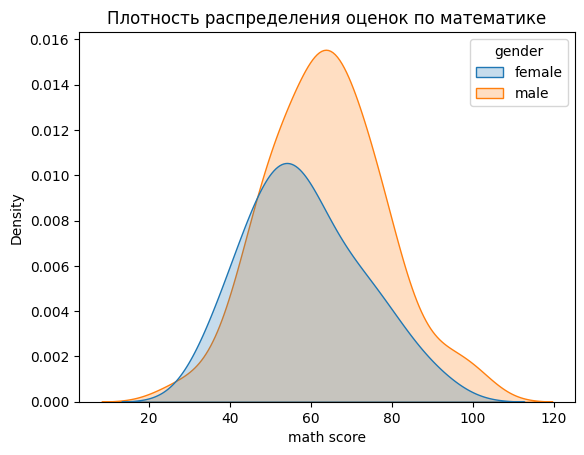

In [21]:
sns.kdeplot(data=df[(df['race/ethnicity'] == 'group A')], x='math score', hue='gender', fill=True)
plt.title('Плотность распределения оценок по математике')
plt.show()

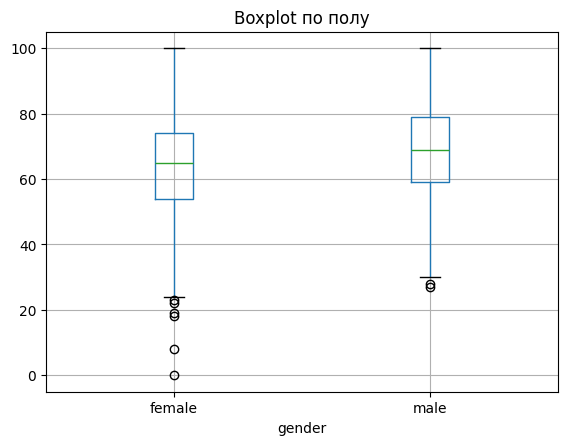

In [22]:
df.boxplot(column='math score', by='gender')
plt.suptitle('')
plt.title('Boxplot по полу')
plt.show()

Очевидно, что номальность присутствует в распределении с незначительными отклонениями

## Проверка равенства дисперсий 

In [23]:
# Levene's test (устойчив к отклонениям от нормальности)
w_stat, p_levene = stats.levene(group_A, group_B)
print(f"Levene's test p = {p_levene:.4f}")
# Если p < 0.05 → дисперсии **неравны** - точно нужен Welch’s.

Levene's test p = 0.9902


Дисперсии групп близки. Можно провести стандартный t-тест. Дополнительно можно провести Welch’s t-test (применяется при различных дисперсиях)

## T-test + T-test (Welch)

In [24]:
t_student, p_student = stats.ttest_ind(group_A, group_B, equal_var=True)
t_welch, p_welch = stats.ttest_ind(group_A, group_B, equal_var=False)

print(f"Student's t-test:  t = {t_student:.3f}, p = {p_student:.4f}")
if p_student < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")
print(f"Welch's t-test:    t = {t_welch:.3f}, p = {p_welch:.4f}")
if p_welch < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")

Student's t-test:  t = -1.677, p = 0.0970
Статистически значимых различий нет.
Welch's t-test:    t = -1.686, p = 0.0959
Статистически значимых различий нет.


Добавим еще один тест Mann-Whitney U test (не требует нормального распределения и устойчив к выбросам, однако не такой мощный как t-test)

## Mann-Whitney U test

In [25]:
# Mann-Whitney U test (непараметрический)
u, p = stats.mannwhitneyu(group_A, group_B, alternative='two-sided')
print(f"Mann-Whitney U test: p = {p:.4f}")

if p < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")

Mann-Whitney U test: p = 0.0791
Статистически значимых различий нет.


#### Вывод: Различия в упеваемости по математике между студентами и студентками в группе А не яляются статистически значимыми (при α = 0.05)

### 1.2. Различия успеваемости по чтению группы А

In [26]:
group_A = df[(df['gender'] == 'female') & (df['race/ethnicity'] == 'group A')]['reading score']
group_B = df[(df['gender'] == 'male') & (df['race/ethnicity'] == 'group A')]['reading score']
shapiro_A = stats.shapiro(group_A)
shapiro_B = stats.shapiro(group_B)
print("Shapiro A p =", shapiro_A.pvalue)
if shapiro_A.pvalue > 0.05:
    print ('- распределение близко к нормальному')
else:
    print('- не нормальное распределение')
print("Shapiro B p =", shapiro_B.pvalue)
if shapiro_B.pvalue > 0.05:
    print ('- распределение близко к нормальному')
else:
    print('- не нормальное распределение')

Shapiro A p = 0.5536471127732417
- распределение близко к нормальному
Shapiro B p = 0.9430361921317141
- распределение близко к нормальному


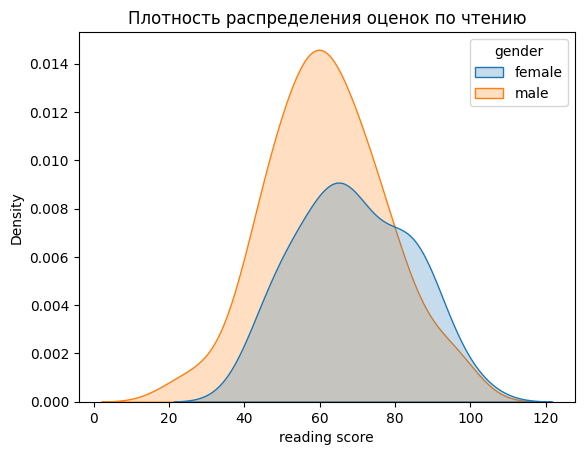

In [27]:
sns.kdeplot(data=df[(df['race/ethnicity'] == 'group A')], x='reading score', hue='gender', fill=True)
plt.title('Плотность распределения оценок по чтению')
plt.show()

In [28]:
# Levene's test (устойчив к отклонениям от нормальности)
w_stat, p_levene = stats.levene(group_A, group_B)
print(f"Levene's test p = {p_levene:.4f}")
# Если p < 0.05 → дисперсии **неравны** → точно нужен Welch’s.

t_student, p_student = stats.ttest_ind(group_A, group_B, equal_var=True)
t_welch, p_welch = stats.ttest_ind(group_A, group_B, equal_var=False)

print(f"Student's t-test:  t = {t_student:.3f}, p = {p_student:.4f}")
if p_student < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")
print(f"Welch's t-test:    t = {t_welch:.3f}, p = {p_welch:.4f}")
if p_welch < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")
# Mann-Whitney U test (непараметрический)
u, p = stats.mannwhitneyu(group_A, group_B, alternative='two-sided')
print(f"Mann-Whitney U test: p = {p:.4f}")

if p < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")

Levene's test p = 0.9178
Student's t-test:  t = 2.211, p = 0.0296
Различия статистически значимы.
Welch's t-test:    t = 2.228, p = 0.0288
Различия статистически значимы.
Mann-Whitney U test: p = 0.0377
Различия статистически значимы.


#### Вывод: Различия в упеваемости по чтению между студентами и студентками в группе А являются статистически значимыми (α = 0.05)

### 1.3. Различия успеваемости по письму группы А

In [29]:
group_A = df[(df['gender'] == 'female') & (df['race/ethnicity'] == 'group A')]['writing score']
group_B = df[(df['gender'] == 'male') & (df['race/ethnicity'] == 'group A')]['writing score']
shapiro_A = stats.shapiro(group_A)
shapiro_B = stats.shapiro(group_B)
print("Shapiro A p =", shapiro_A.pvalue)
if shapiro_A.pvalue > 0.05:
    print ('- распределение близко к нормальному')
else:
    print('- не нормальное распределение')
print("Shapiro B p =", shapiro_B.pvalue)
if shapiro_B.pvalue > 0.05:
    print ('- распределение близко к нормальному')
else:
    print('- не нормальное распределение')

Shapiro A p = 0.8216986381195888
- распределение близко к нормальному
Shapiro B p = 0.6918718915671099
- распределение близко к нормальному


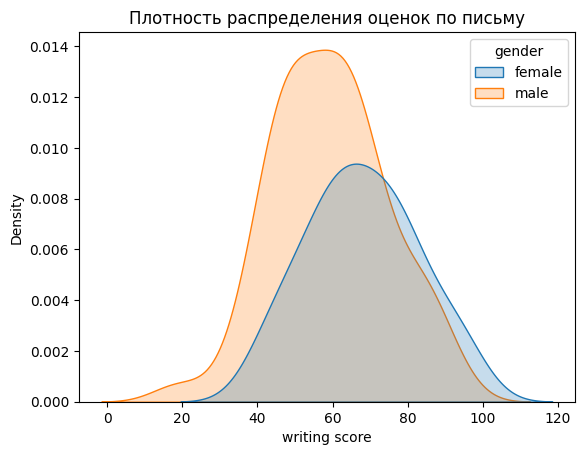

In [30]:
sns.kdeplot(data=df[(df['race/ethnicity'] == 'group A')], x='writing score', hue='gender', fill=True)
plt.title('Плотность распределения оценок по письму')
plt.show()

In [31]:
# Levene's test (устойчив к отклонениям от нормальности)
w_stat, p_levene = stats.levene(group_A, group_B)
print(f"Levene's test p = {p_levene:.4f}")
# Если p < 0.05 → дисперсии **неравны** → точно нужен Welch’s.

t_student, p_student = stats.ttest_ind(group_A, group_B, equal_var=True)
t_welch, p_welch = stats.ttest_ind(group_A, group_B, equal_var=False)

print(f"Student's t-test:  t = {t_student:.3f}, p = {p_student:.4f}")
if p_student < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")
print(f"Welch's t-test:    t = {t_welch:.3f}, p = {p_welch:.4f}")
if p_welch < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")
# Mann-Whitney U test (непараметрический)
u, p = stats.mannwhitneyu(group_A, group_B, alternative='two-sided')
print(f"Mann-Whitney U test: p = {p:.4f}")

if p < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")

Levene's test p = 0.8927
Student's t-test:  t = 2.699, p = 0.0084
Различия статистически значимы.
Welch's t-test:    t = 2.716, p = 0.0082
Различия статистически значимы.
Mann-Whitney U test: p = 0.0113
Различия статистически значимы.


#### Вывод: Различия в упеваемости по письму между студентами и студентками в группе А являются статистически значимыми (α = 0.05)

## 2. Н0 - Влияние питания на успеваемость учеников

### 2.1. Рассмотрим оценки студентов по математике

In [32]:
# Создаем группы учеников с платным и бесплатным питанием
group_A = df[(df['lunch'] == 'standard')]['math score']
group_B = df[(df['lunch'] == 'free/reduced')]['math score']

In [33]:
# Узнаем количество студентов в каждой группе
print (len(group_A))
print (len(group_B))

645
355


In [34]:
# Levene's test (устойчив к отклонениям от нормальности)
w_stat, p_levene = stats.levene(group_A, group_B)
print(f"Levene's test p = {p_levene:.4f}")
# Если p < 0.05 → дисперсии **неравны** → точно нужен Welch’s.

Levene's test p = 0.0742


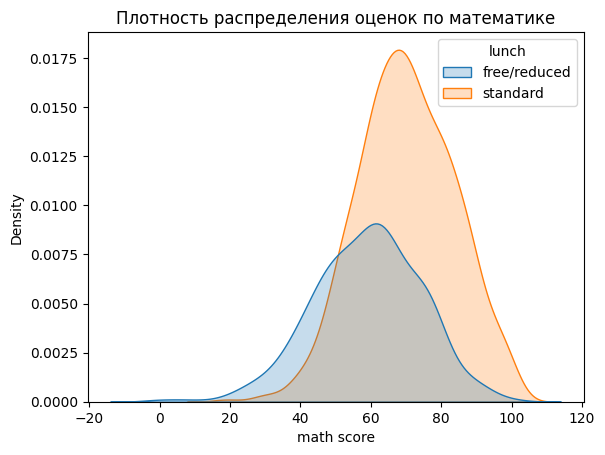

In [35]:
sns.kdeplot(data=df, x='math score', hue='lunch', fill=True)
plt.title('Плотность распределения оценок по математике')
plt.show()

In [36]:
t_student, p_student = stats.ttest_ind(group_A, group_B, equal_var=True)
t_welch, p_welch = stats.ttest_ind(group_A, group_B, equal_var=False)

print(f"Student's t-test:  t = {t_student:.3f}, p = {p_student:.14f}")
if p_student < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")
print(f"Welch's t-test:    t = {t_welch:.3f}, p = {p_welch:.34f}")
if p_welch < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")
# Mann-Whitney U test (непараметрический)
u, p = stats.mannwhitneyu(group_A, group_B, alternative='two-sided')
print(f"Mann-Whitney U test: p = {p:.4f}")

if p < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")

Student's t-test:  t = 11.837, p = 0.00000000000000
Различия статистически значимы.
Welch's t-test:    t = 11.484, p = 0.0000000000000000000000000005539585
Различия статистически значимы.
Mann-Whitney U test: p = 0.0000
Различия статистически значимы.


In [37]:
df['parental level of education'].unique()

['bachelor's degree', 'some college', 'master's degree', 'associate's degree', 'high school', 'some high school']
Categories (6, object): ['associate's degree', 'bachelor's degree', 'high school', 'master's degree', 'some college', 'some high school']

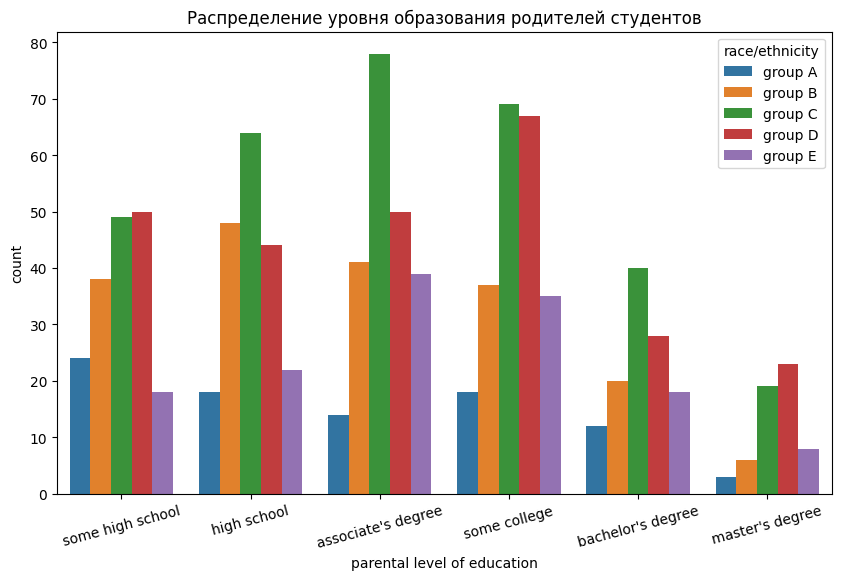

In [38]:
# уупорядочим уровни образования
edu_order = [
    'some high school',
    'high school',
    'associate\'s degree',
    'some college',
    'bachelor\'s degree',
    'master\'s degree']
df['parental level of education'] = pd.Categorical(
    df['parental level of education'],
    categories=edu_order,
    ordered=True)
# выведем график
plt.figure(figsize=(10, 6))
plt.title('Распределение уровня образования родителей студентов')
sns.countplot(df, x = 'parental level of education',hue='race/ethnicity')
plt.xticks(rotation=15)
plt.show()

In [39]:
group_par_edu = pd.crosstab(
    df['race/ethnicity'],
    df['parental level of education'], 
    normalize='index', 
) * 100
group_par_edu['Total'] = group_par_edu.sum(axis=1)
group_par_edu = group_par_edu.round(1).astype(int)

group_par_edu

parental level of education,some high school,high school,associate's degree,some college,bachelor's degree,master's degree,Total
race/ethnicity,,,,,,,
group A,27,20,15,20,13,3,100
group B,20,25,21,19,10,3,100
group C,15,20,24,21,12,6,100
group D,19,16,19,25,10,8,100
group E,12,15,27,25,12,5,100


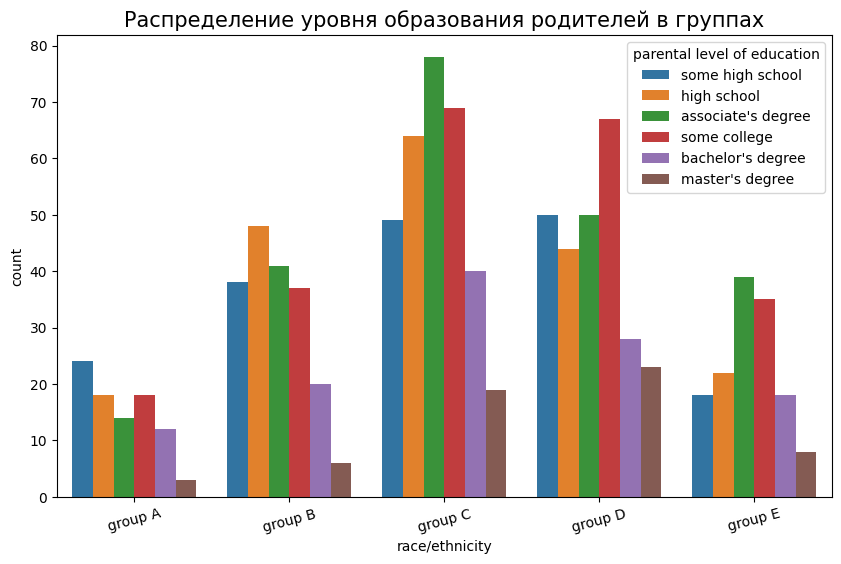

In [40]:
plt.figure(figsize=(10, 6))
plt.title('Распределение уровня образования родителей в группах', fontsize = 15)
sns.countplot(df, x = 'race/ethnicity',hue='parental level of education')
plt.xticks(rotation=15)
plt.show()

## Оценка эффективности подготовительных курсов

### Сколько студентов прошли курсы в каждой из групп

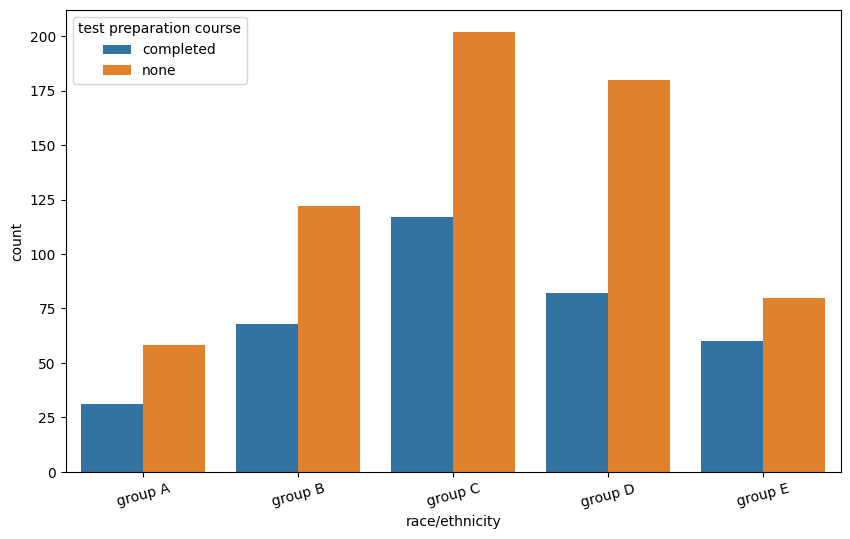

In [41]:
plt.figure(figsize=(10, 6))
sns.countplot(df, x = 'race/ethnicity',hue='test preparation course')
plt.xticks(rotation=15)
plt.show()

In [42]:
avgscore_df = df.groupby(['gender', 'race/ethnicity'], observed=True).agg(
    math_avg=('math score', 'mean'),
    reading_avg=('reading score', 'mean'),
    writing_avg=('writing score', 'mean')
).round().astype(int).reset_index()
avgscore_df

,gender,race/ethnicity,math_avg,reading_avg,writing_avg
0,female,group A,59,69,68
1,female,group B,61,71,70
2,female,group C,62,72,72
3,female,group D,65,74,75
4,female,group E,71,76,76
5,male,group A,64,62,59
6,male,group B,66,63,60
7,male,group C,68,65,63
8,male,group D,69,66,65
9,male,group E,77,70,67


In [43]:
# выберем студетнов прошедших подготовительные курсы
df_prep = df[df['test preparation course'] == 'completed']
# рассчитаем их средние оценки
avgscore_df_prep = df_prep.groupby(['gender', 'race/ethnicity'], observed=True).agg(
    math_avg_prep=('math score', 'mean'),
    reading_avg_prep=('reading score', 'mean'),
    writing_avg_prep=('writing score', 'mean')
).round().astype(int).reset_index()
avgscore_df_prep

,gender,race/ethnicity,math_avg_prep,reading_avg_prep,writing_avg_prep
0,female,group A,68,77,77
1,female,group B,63,75,74
2,female,group C,66,77,79
3,female,group D,68,77,80
4,female,group E,76,82,83
5,male,group A,69,67,67
6,male,group B,72,71,69
7,male,group C,70,68,68
8,male,group D,72,70,72
9,male,group E,79,73,71


In [44]:
# выберем студетнов непрошедших подготовительные курсы
df_noprep = df[df['test preparation course'] == 'none']
# рассчитаем их средние оценки
avgscore_df_noprep = df_noprep.groupby(['gender', 'race/ethnicity'], observed=True).agg(
    math_avg_noprep=('math score', 'mean'),
    reading_avg_noprep=('reading score', 'mean'),
    writing_avg_noprep=('writing score', 'mean')
).round().astype(int).reset_index()
avgscore_df_noprep

,gender,race/ethnicity,math_avg_noprep,reading_avg_noprep,writing_avg_noprep
0,female,group A,54,65,64
1,female,group B,61,69,68
2,female,group C,60,69,67
3,female,group D,64,72,72
4,female,group E,68,73,72
5,male,group A,61,59,55
6,male,group B,62,58,55
7,male,group C,67,64,60
8,male,group D,68,64,63
9,male,group E,75,67,63


## Создадим сводную таблицу, где ставним средние оценки студентов непрошедших подготовительные курсы, без учета и прошедших.

In [45]:
df_comp_avg_prep = pd.concat([
    avgscore_df[['gender']].rename(columns = {'gender' : 'Пол'}),
    avgscore_df[['race/ethnicity']].rename(columns = {'race/ethnicity' : 'Группа'}),
    avgscore_df_noprep[['math_avg_noprep']].rename(columns = {'math_avg_noprep' : 'Матем.без курсов'}),
    avgscore_df[['math_avg']].rename(columns = {'math_avg' : 'Математика'}),
    avgscore_df_prep[['math_avg_prep']].rename(columns = {'math_avg_prep' : 'Матем.с курсами'}),
    avgscore_df_noprep[['reading_avg_noprep']].rename(columns = {'reading_avg_noprep' : 'Чтение без курсов'}),
    avgscore_df[['reading_avg']].rename(columns = {'reading_avg' : 'Чтение'}),
    avgscore_df_prep[['reading_avg_prep']].rename(columns = {'reading_avg_prep' : 'Чтение с курсами'}),
    avgscore_df_noprep[['writing_avg_noprep']].rename(columns = {'writing_avg_noprep' : 'Письмо без курсов'}),
    avgscore_df[['writing_avg']].rename(columns = {'writing_avg' : 'Письмо'}),
    avgscore_df_prep[['writing_avg_prep']].rename(columns = {'writing_avg_prep' : 'Письмо с курсами'})
],axis=1)
df_comp_avg_prep.style.set_properties(**{'width': '150px', 'text-align': 'center'})

,Пол,Группа,Матем.без курсов,Математика,Матем.с курсами,Чтение без курсов,Чтение,Чтение с курсами,Письмо без курсов,Письмо,Письмо с курсами
0,female,group A,54,59,68,65,69,77,64,68,77
1,female,group B,61,61,63,69,71,75,68,70,74
2,female,group C,60,62,66,69,72,77,67,72,79
3,female,group D,64,65,68,72,74,77,72,75,80
4,female,group E,68,71,76,73,76,82,72,76,83
5,male,group A,61,64,69,59,62,67,55,59,67
6,male,group B,62,66,72,58,63,71,55,60,69
7,male,group C,67,68,70,64,65,68,60,63,68
8,male,group D,68,69,72,64,66,70,63,65,72
9,male,group E,75,77,79,67,70,73,63,67,71


## Определение статистической значимости подготовительных курсов в отношении упеваемости

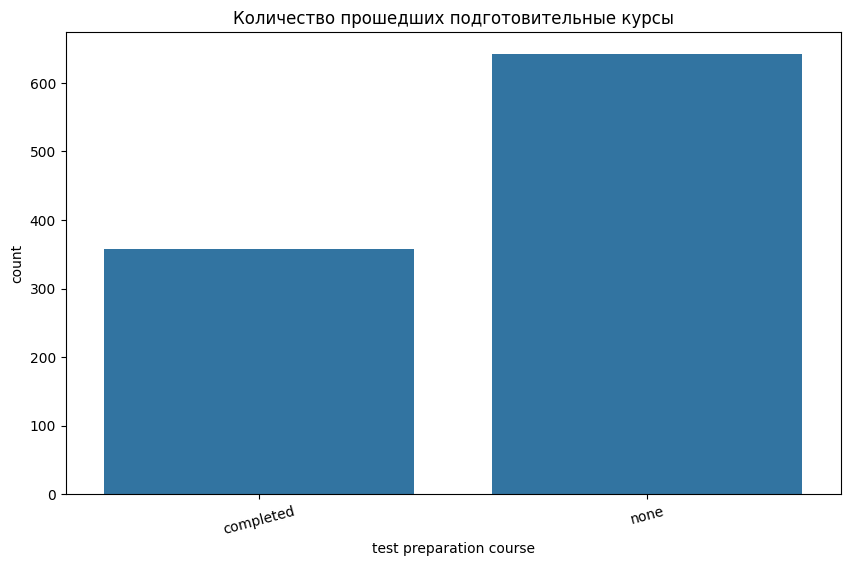

Прошло подготовительные курсы: 358 студентов
Не прошло подготовительные курсы: 642 студентов


In [46]:
plt.figure(figsize=(10, 6))
plt.title('Количество прошедших подготовительные курсы')
sns.countplot(df, x='test preparation course')
plt.xticks(rotation=15)
plt.show()
print('Прошло подготовительные курсы:',len(df[df['test preparation course'] == 'completed']), 'студентов')
print('Не прошло подготовительные курсы:',len(df[df['test preparation course'] == 'none']), 'студентов')

In [47]:
group_prep = df[(df['test preparation course'] == 'completed')]['math score']
group_noprep = df[(df['test preparation course'] == 'none')]['math score']

In [48]:
# Levene's test на равенство дисперсий (устойчив к отклонениям от нормальности)
w_stat, p_levene = stats.levene(group_prep, group_noprep)
print(f"Levene's test p = {p_levene:.4f}")
# Если p < 0.05 → дисперсии **неравны** → точно нужен Welch’s.

Levene's test p = 0.4655


In [49]:
shapiro_A = stats.shapiro(group_prep)
shapiro_B = stats.shapiro(group_noprep)
print("Shapiro A p =", shapiro_A.pvalue)
if shapiro_A.pvalue > 0.05:
    print ('- распределение близко к нормальному')
else:
    print('- не нормальное распределение')
print("Shapiro B p =", shapiro_B.pvalue)
if shapiro_B.pvalue > 0.05:
    print ('- распределение близко к нормальному')
else:
    print('- не нормальное распределение')

Shapiro A p = 0.1393494159012535
- распределение близко к нормальному
Shapiro B p = 0.0017542243871878584
- не нормальное распределение


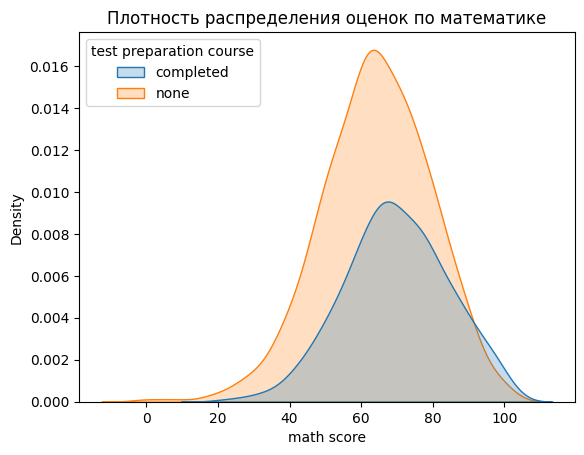

In [50]:
sns.kdeplot(data=df, x='math score', hue='test preparation course', fill=True)
plt.title('Плотность распределения оценок по математике')
plt.show()

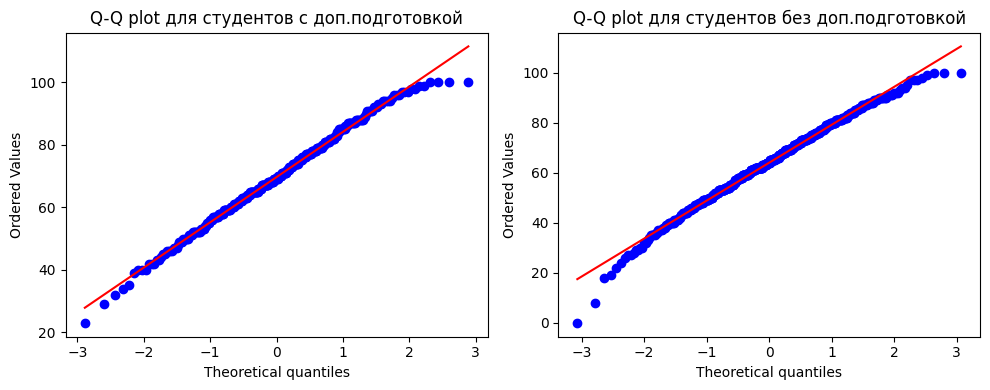

In [51]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
stats.probplot(group_prep, dist="norm", plot=plt)
plt.title("Q-Q plot для студентов с доп.подготовкой")

plt.subplot(1, 2, 2)
stats.probplot(group_noprep, dist="norm", plot=plt)
plt.title("Q-Q plot для студентов без доп.подготовкой")

plt.tight_layout()
plt.show()

In [52]:
t_student, p_student = stats.ttest_ind(group_prep, group_noprep, equal_var=True)
t_welch, p_welch = stats.ttest_ind(group_prep, group_noprep, equal_var=False)

print(f"Student's t-test:  t = {t_student:.3f}, p = {p_student:.10f}")
if p_student < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")
print(f"Welch's t-test:    t = {t_welch:.3f}, p = {p_welch:.10f}")
if p_welch < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")
# Mann-Whitney U test (непараметрический)
u, p = stats.mannwhitneyu(group_prep, group_noprep, alternative='two-sided')
print(f"Mann-Whitney U test: p = {p:.10f}")

if p < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")

Student's t-test:  t = 5.705, p = 0.0000000154
Различия статистически значимы.
Welch's t-test:    t = 5.787, p = 0.0000000104
Различия статистически значимы.
Mann-Whitney U test: p = 0.0000000802
Различия статистически значимы.


In [53]:
# Данные
A = df[(df['test preparation course'] == 'completed')]['math score']
B = df[(df['test preparation course'] == 'none')]['math score']

# Средние и std
mean_A, mean_B = A.mean(), B.mean()
std_A, std_B = A.std(ddof=1), B.std(ddof=1)
n_A, n_B = len(A), len(B)

# Cohen's d (с объединённым std)
pooled_std = np.sqrt(((n_A - 1)*std_A**2 + (n_B - 1)*std_B**2) / (n_A + n_B - 2))
cohens_d = (mean_A - mean_B) / pooled_std

# Доверительный интервал для разницы средних (Welch)
diff = mean_A - mean_B
se = np.sqrt(std_A**2/n_A + std_B**2/n_B)  # стандартная ошибка
df_welch = (std_A**2/n_A + std_B**2/n_B)**2 / ((std_A**2/n_A)**2/(n_A-1) + (std_B**2/n_B)**2/(n_B-1))
t_crit = stats.t.ppf(0.975, df_welch)
ci_low = diff - t_crit * se
ci_high = diff + t_crit * se

print(f"Разница: {diff:.2f} (+ {diff:.2f} балла у прошедших курсы)")
print(f"Cohen's d: {cohens_d:.3f}")
print(f"95% ДИ: [{ci_low:.2f}, {ci_high:.2f}]")

Разница: 5.62 (+ 5.62 балла у прошедших курсы)
Cohen's d: 0.376
95% ДИ: [3.71, 7.52]


Прохождение подготовительных курсов положительно связано с успеваемостью по математике. Студенты, завершившие курсы, в среднем набирают на 5.6 баллов больше (95% ДИ: [3.71, 7.52]), чем их сверстники без подготовки. Размер эффекта умеренный (Cohen’s d = 0.38).

### Использование статистической модели (OLS Regression) для определения зависимости успеваемости по математике от пола, питания и подготовительных курсов

In [54]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
# Переименуем столбцы один раз в начале анализа
df = df.rename(columns={
    'math score': 'math_score',
    'reading score': 'reading_score',
    'writing score': 'writing_score',
    'test preparation course': 'test_prep_course'
})
df['test_prep_course'] = pd.Categorical(df['test_prep_course'], categories=['none', 'completed'])
# Теперь формула работает без кавычек
model = sm.OLS.from_formula('math_score ~ C(test_prep_course) + gender + lunch', data=df)

In [55]:
# Подгоняем модель к данным
result = model.fit()

In [56]:
# Тест Бреуша-Пагана на гетероскедастичность
bp_stat, bp_p, bp_f, bp_f_p = het_breuschpagan(result.resid, result.model.exog)

print(f"Тест Бреуша-Пагана на гетероскедастичность:")
print(f"  p-value = {bp_p:.4f}")

if bp_p < 0.05:
    print("Гетероскедастичность обнаружена. Рекомендуется использовать робастные стандартные ошибки. result_robust = model.fit(cov_type='HC3')")
else:
    print("Гетероскедастичность не обнаружена. nonrobust — допустимо.")

Тест Бреуша-Пагана на гетероскедастичность:
  p-value = 0.1257
Гетероскедастичность не обнаружена. nonrobust — допустимо.


In [57]:
# Выведем подробную статистику
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:             math_score   R-squared:                       0.182
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     73.99
Date:                Wed, 07 Jan 2026   Prob (F-statistic):           3.29e-43
Time:                        13:19:45   Log-Likelihood:                -4036.7
No. Observations:                1000   AIC:                             8081.
Df Residuals:                     996   BIC:                             8101.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

### Результаты анализа
Была использована статистическая модель Наименьших квадратов (Ordinary Least Squares - OLS):</br>
Совместный вклад в дисперсию этих трех параметров оказывается равным <b>18%</b><br>
За базовое значение приняты следующие параметры: Пол - <b>Женский</b>, Подготовительный курс - <b>Не пройден</b>, Питание - <b>Бесплатное</b></br>
Средний балл контрольной группы составляет <b> 54.5 балла (95% ДИ: [52.8, 56.3]) </b> </br>
Подготовительные курсы дают преимущество в среднем в <b>+5.8 балла (95% ДИ: [4, 7,5])</b></br>
Студенты мужского пола набирают в среднем больше на <b> 4.8 балла (95% ДИ: [3.1, 6.5])</b></br>
Стеденты с платным питанием успешнее на <b> 11.1 балла (95% ДИ: [9.3, 12.9]) </b></br>
Модель объясняет <b>18.2%</b> дисперсии оценок по математике (R² = 0.182, скорректированный R² = 0.180), что является умеренным, но значимым уровнем объяснённой вариации для образовательных данных.<br><br>
<b>Тесты на нормальность:</b></br>
- Нормальность остатков(residuals): Prob(Omnibus): <b>p = 0.100 > 0.05</b> и Prob(JB):<b>p = 0.102 > 0.05</b>, что подтверждает нормальность остатков и верность расчета t-статистики </br>
- Асимметрия (skewness) = <b>-0.166</b> , что указывает на небольшую левостороннюю ассиметрию<br>
- Эксцесс (kurtosis) = <b>3.011</b> что очень близко к идеальному значению (При нормальном распределении kurtosis = 3)<br><br>
<b>Тест на автокорреляцию (Durbin-Watson):</b><br>
 Durbin-Watson = <b>2.101</b> ≈ 2 Можно заключить, что автокорреляция отсутствует.<br>
<b>Тест на мультиколлинеарность(Condition Number) :</b><br>
 Cond. No. = <b>3.88</b> - Мультиколлиниарность (коллинеарность между независимыми переменными) отсутствует. Для информации: < 10 - мультиколлинеарности нет, 10–30 - умеренная,
30 - сильная.<br>
<b>F-статистика:</b></br>
Модель, включающая подготовительные курсы, пол и тип питания, статистически значимо объясняет вариацию оценок по математике (F(3, 996) = 73.99, p < 0.001). Это означает, что наблюдаемая связь между предикторами и оценками крайне маловероятно возникла случайно.»<br>
<br><b>Данные для оценки эффективности модели:</b>
<br>Текущие значения для трех выбранных переменных (чем меньше, тем лучше)
<br>Log-Likelihood (логарифм функции правдоподобия): -4036.7
<br>Akaike’s information criterion (AIC) : 8081.
<br>Schwarz’s Bayesian information criterion (BIC or SBC): 8101.
<br>
<br>**AIC (Akaike Information Criterion):**
$$
\text{AIC} = -2 \cdot \log(\mathcal{L}) + 2k
$$
**BIC (Bayesian Information Criterion):**
$$
\text{BIC} = -2 \cdot \log(\mathcal{L}) + k \cdot \ln(n)
$$
где:  
- $\log(\mathcal{L})$ — логарифм функции правдоподобия (Log-Likelihood),  
- $k$ — число оцениваемых параметров модели (включая intercept),  
- $n$ — количество наблюдений.
<br>

In [65]:
# Частичный ANOVA (Type II — рекомендуется для независимых переменных без взаимодействий)
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
anova_table = anova_lm(result, typ=2)

print("=== Partial ANOVA Results ===")
print(anova_table)

=== Partial ANOVA Results ===
                            sum_sq     df           F        PR(>F)
C(test_prep_course)    7665.750544    1.0   40.649582  2.781879e-10
gender                 5832.258900    1.0   30.927029  3.441170e-08
lunch                 28209.747272    1.0  149.589324  3.790045e-32
Residual             187826.961859  996.0         NaN           NaN


Гетероскедастичность не была подтвержена, но они зачастую присутствует в в социальных и образовательных данных. Используем в модели робастные оценки типа HC3 и выведем результаты

In [58]:
result_robust = model.fit(cov_type='HC3')
print(result_robust.summary())

                            OLS Regression Results                            
Dep. Variable:             math_score   R-squared:                       0.182
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     69.84
Date:                Wed, 07 Jan 2026   Prob (F-statistic):           5.39e-41
Time:                        13:19:45   Log-Likelihood:                -4036.7
No. Observations:                1000   AIC:                             8081.
Df Residuals:                     996   BIC:                             8101.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

Изменения в доверительных интервалах по сравнению с неробастными значениями незначительны

### Зависимость успеваемости от образования родителей (Модель OLS Regression)

In [59]:
df = df.rename(columns={'parental level of education': 'parental_level_of_education'})
model_par_edu = sm.OLS.from_formula('math_score ~ C(parental_level_of_education)', data=df)
result_par_edu = model_par_edu.fit()
print(result_par_edu.summary())

                            OLS Regression Results                            
Dep. Variable:             math_score   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     6.522
Date:                Wed, 07 Jan 2026   Prob (F-statistic):           5.59e-06
Time:                        13:19:45   Log-Likelihood:                -4121.2
No. Observations:                1000   AIC:                             8254.
Df Residuals:                     994   BIC:                             8284.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

### Вывод:
Уровень образования родитилей вносит всего лишь <b>3.2%</b> в дисперсию, но при этом видна зависимость: <br>
<b>Чем выше уровень образования, тем выше оценки по математике у их детей.</b><br>
Средний балл учеников с родителями с неоконченным средним образованием по математике - <b>63.5</b> <br>
С полным средним образованием<b> меньше на 1.4 балла</b> <br>
С <b>неоконченным</b> высшим образованием <b>больше на 3.6 балла</b> <br>
Со средним специальным <b>больше на 4.4 балла</b> <br>
С бакалавриатом <b>больше на 5.9 балла</b> <br>
С магистратурой <b>больше на 6.2 балла</b> <br>

<br>

### Зависимость успеваемости от принадлежности к этнической группе (Модель OLS Regression)

In [60]:
df = df.rename(columns={'race/ethnicity': 'race_ethnicity'})
model_group = sm.OLS.from_formula('math_score ~ C(race_ethnicity)', data=df)
result_group = model_group.fit()
print(result_group.summary())

                            OLS Regression Results                            
Dep. Variable:             math_score   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     14.59
Date:                Wed, 07 Jan 2026   Prob (F-statistic):           1.37e-11
Time:                        13:19:45   Log-Likelihood:                -4108.8
No. Observations:                1000   AIC:                             8228.
Df Residuals:                     995   BIC:                             8252.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

### Вывод:
Принадлежность к той или иной этнической группе вносит <b>5.5%</b> в дисперсию: <br>
Средний балл учеников по математике группы A - <b>61.6</b> <br>
Группы B<b> больше на 1.8 балла</b> <br>
Группы C<b> больше на 2.8 балла</b> <br>
Группы D<b> больше на 5.7 балла</b> <br>
Группы E<b> больше на 12.2 балла</b> <br>

<b>Сделаем предположение, что более состоятельные студенты имеют возможность пройти подготовительные курсы и получить платное питание. Каким будет совместный эффект на успеваемость?</b>

In [61]:
model_prep_and_lunch = sm.OLS.from_formula('math_score ~ test_prep_course*lunch', data=df)
result_prep_and_lunch = model_prep_and_lunch.fit()
print(result_prep_and_lunch.summary())

                            OLS Regression Results                            
Dep. Variable:             math_score   R-squared:                       0.157
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     61.91
Date:                Wed, 07 Jan 2026   Prob (F-statistic):           1.05e-36
Time:                        13:19:45   Log-Likelihood:                -4051.8
No. Observations:                1000   AIC:                             8112.
Df Residuals:                     996   BIC:                             8131.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------

<b>Взаимодействие между подготовительными курсами и типом школьного питания оказалось статистически незначимым (β = –1.14, p = 0.553), что свидетельствует об отсутствии влияния социально-экономического статуса в эффекте курсов. Таким образом, прохождение курсов повышает баллы по математике в среднем на 6.5 пунктов, независимо от типа питания.</b>
